In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Admission_Predict.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [ ]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.drop('Serial No.', axis=1, inplace=True)

In [ ]:
x=df.drop('Chance of Admit ', axis=1)
y=df['Chance of Admit ']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=5)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mm=MinMaxScaler()
xtrain=mm.fit_transform(x_train)
xtest=mm.transform(x_test)

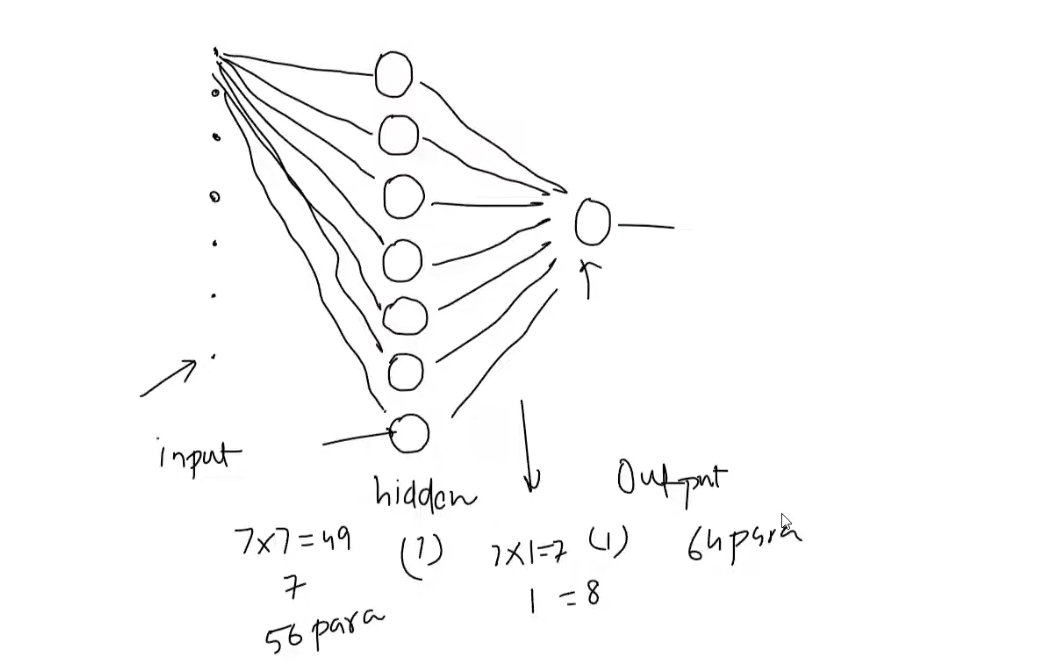

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()

model.add(Dense(7, activation='relu', input_dim=7))
#adding 1 more hidden layer because r2 score was in -71.82
model.add(Dense(7, activation='relu'))
model.add(Dense(1, activation='linear'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='mean_squared_error', optimizer='Adam')

In [ ]:
model_history=model.fit(xtrain, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0979 - val_loss: 0.0604
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0514 - val_loss: 0.0337
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0296 - val_loss: 0.0210
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0190 - val_loss: 0.0172
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0189 - val_loss: 0.0152
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0156 - val_loss: 0.0128
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0133 - val_loss: 0.0103
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 - val_loss: 0.0086
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0094 - val_loss: 0.0079
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0085 - val_loss: 0.0077
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - val_loss: 0.0076
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0071 - val

In [ ]:
y_pred=model.predict(xtest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.7676908578516263

In [ ]:
model_history.history

{'loss': [0.08165047317743301,
  0.04632257670164108,
  0.02732866443693638,
  0.019534882158041,
  0.017583709210157394,
  0.015199613757431507,
  0.01244652085006237,
  0.010040076449513435,
  0.008542771451175213,
  0.007780319545418024,
  0.0075501627288758755,
  0.007300324738025665,
  0.007140784524381161,
  0.007006110157817602,
  0.006854058708995581,
  0.006740695331245661,
  0.0066263205371797085,
  0.006530832499265671,
  0.006428930908441544,
  0.00632142648100853,
  0.006242191419005394,
  0.006159589625895023,
  0.006059478968381882,
  0.005994571838527918,
  0.005935182794928551,
  0.0058640907518565655,
  0.00579520408064127,
  0.005719490349292755,
  0.005656192544847727,
  0.005602025892585516,
  0.005549167282879353,
  0.005499299615621567,
  0.005447626579552889,
  0.0053986115381121635,
  0.005365913268178701,
  0.0053178975358605385,
  0.005294942297041416,
  0.005278720986098051,
  0.005196322686970234,
  0.0051710037514567375,
  0.005153701640665531,
  0.0050849

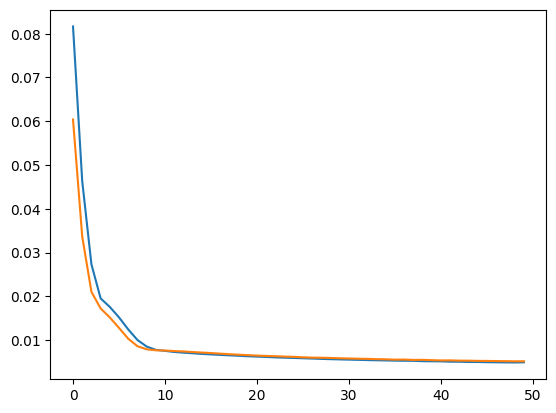

In [ ]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])

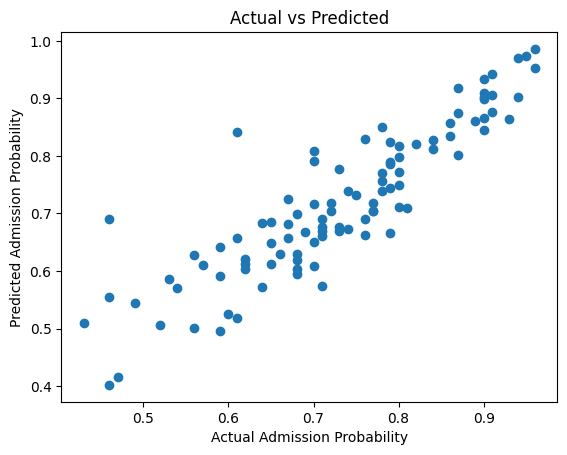

In [33]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Admission Probability")
plt.ylabel("Predicted Admission Probability")
plt.title("Actual vs Predicted")
plt.show()